# Netflix Movies & TV Shows Dataset   
*Data Cleaning & EDA*    
**Dataset:** [Netflix Movies and TV Shows (Kaggle)](https://www.kaggle.com/datasets/shivamb/netflix-shows)

Dataset understanding, data cleaning, exploratory data analysis, and visualization for
Netflix's catalog listing (titles available as of the data's snapshot date). 

Focus is the **cleaning process**    
*every decision is documented as it's made.*

In [1]:
import pandas as pd
from plotnine import *
import numpy as np
import seaborn as sns

In [2]:
from cleaning_utils import *
from eda_utils import *

In [3]:
netflix_raw = pd.read_csv('netflix_titles.csv')

## Dataset Understanding

In [4]:
netflix_raw.sample(20)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
2047,s2048,TV Show,Spirit Riding Free: Riding Academy,NaN,"Amber Frank, Bailey Gambertoglio, Sydney Park,...",United States,"September 4, 2020",2020,TV-Y7,2 Seasons,Kids' TV,A new chapter begins for Lucky and her friends...
6354,s6355,Movie,Bolt,"Byron Howard, Chris Williams","John Travolta, Miley Cyrus, Susie Essman, Mark...",United States,"July 22, 2018",2008,PG,99 min,"Children & Family Movies, Comedies","This tale follows German shepherd Bolt, a cani..."
6631,s6632,Movie,Don't Look Down,Daniel Gordon,Richard Branson,United Kingdom,"April 1, 2017",2016,TV-MA,93 min,"Documentaries, International Movies",Aided by dramatic reconstructions and archive ...
3691,s3692,TV Show,DreamWorks Kung Fu Panda Awesome Secrets,NaN,"Jack Black, Dustin Hoffman, Dennis Haysbert, P...",United States,"July 1, 2019",2008,TV-PG,1 Season,"Kids' TV, TV Action & Adventure, TV Comedies","In this pair of adventures, Po tells the story..."
3115,s3116,Movie,The First Lady,Omoni Oboli,"Omoni Oboli, Alexx Ekubo, Chinedu Ikedieze, Jo...",NaN,"December 20, 2019",2015,TV-MA,107 min,"Dramas, International Movies","Dreaming of a better life, an imperiled prosti..."
5712,s5713,Movie,Donald Glover: Weirdo,"Shannon Hartman, Michelle Caputo",Donald Glover,United States,"November 19, 2016",2012,TV-MA,65 min,Stand-Up Comedy,Fearlessly funny stand-up comic and sitcom sta...
733,s734,TV Show,LEGO Friends: The Power of Friendship,NaN,"Erica Mendez, Marianne Miller, Rachelle Heger,...",Denmark,"June 11, 2021",2016,TV-Y7,2 Seasons,Kids' TV,Five best friends face adventures side by side...
1248,s1249,Movie,Biggie: I Got a Story to Tell,Emmett Malloy,"The Notorious B.I.G., Sean ""P. Diddy"" Combs",United States,"March 1, 2021",2021,R,98 min,"Documentaries, Music & Musicals",Featuring rare footage and in-depth interviews...
7531,s7532,Movie,My Babysitter's a Vampire: The Movie,Bruce McDonald,"Matthew Knight, Vanessa Morgan, Atticus Mitche...",Canada,"October 17, 2018",2010,TV-PG,80 min,"Children & Family Movies, Comedies","When their parents head out for the evening, E..."
6051,s6052,Movie,A Patch of Fog,Michael Lennox,"Stephen Graham, Conleth Hill, Lara Pulver, Ars...",United Kingdom,"April 15, 2017",2015,TV-MA,92 min,"Dramas, Thrillers",When a guard catches a writer-television host ...


In [5]:
check_unique_values(netflix_raw, 'release_year')

release_year
2018    1147
2017    1032
2019    1030
2020     953
2016     902
        ... 
1961       1
1925       1
1959       1
1966       1
1947       1
Name: count, Length: 74, dtype: int64


In [7]:
netflix_raw['type'].value_counts()

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

In [8]:
netflix_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [9]:
netflix_raw.shape

(8807, 12)

In [10]:
netflix_raw['type'].apply(type).value_counts()

type
<class 'str'>    8807
Name: count, dtype: int64

In [11]:
full_quality_check(netflix_raw)

--- Data types ---
show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object

--- Missing values ---
director      2634
cast           825
country        831
date_added      10
rating           4
duration         3
dtype: int64

--- Duplicates ---
Duplicate rows: 0

--- Constant columns ---
Constant columns: []

--- Outliers (all numeric columns) ---
release_year: 719 potential outliers found.


---
**Column overview**

| Column | Type | Role |
|---|---|---|
| show_id | object | Unique identifier (primary key) |
| type | object | Categorical - Movie or TV Show |
| title | object | Title of the content |
| director | object | Categorical, high missingness |
| cast | object | Categorical, comma-separated list |
| country | object | Categorical, comma-separated list of countries |
| date_added | object → datetime | Date the title was added to Netflix |
| release_year | numerical | Year the content was originally released |
| rating | object | Categorical, content/age rating |
| duration | object | Mixed unit ("90 min" for movies, "2 Seasons" for TV shows) |
| listed_in | object | Categorical, comma-separated list of genres |
| description | object | Free-text synopsis |

- **Numerical features:** `release_year` (the only clean numeric column as-is; `duration` is numeric but
  needs to be split from its unit first)
- **Categorical features:** `type`, `rating`, `country`, `listed_in`, `director`, `cast`
- **Primary key:** `show_id` — confirmed unique for every row.

**What this dataset contains:** a snapshot of Netflix's catalog, with one row per title (movie or TV show),
including cast/crew, country of production, when it was added to Netflix, its original release year, content
rating, runtime/season count, genre tags, and a short synopsis.

## Data Cleaning
### Missing Values

### Standardize column names and text formatting

Text columns are stripped of stray
whitespace.

In [12]:
text_cols = ['type', 'title', 'director', 'cast', 'country', 'rating', 'listed_in', 'description']
strip_whitespace(netflix_raw, text_cols)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
...,...,...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."


### Data validation 

*A quick look at the `rating` column's value counts turns up three values that don't belong there at all:
`"74 min"`, `"84 min"`, `"66 min"`. Checking those rows shows `duration` is blank for exactly those three -
the duration value was shifted one column to the left during whatever process created this CSV. This is
fixed by moving the value back to `duration` and clearing the invalid `rating`.*

In [13]:
shift_mask = netflix_raw['rating'].isin(['74 min', '84 min', '66 min'])
print("Rows with duration shifted into rating:", shift_mask.sum())
print(netflix_raw.loc[shift_mask, ['title', 'rating', 'duration']])

netflix_raw.loc[shift_mask, 'duration'] = netflix_raw.loc[shift_mask, 'rating']
netflix_raw.loc[shift_mask, 'rating'] = np.nan

Rows with duration shifted into rating: 3
                                     title  rating duration
5541                       Louis C.K. 2017  74 min      NaN
5794                 Louis C.K.: Hilarious  84 min      NaN
5813  Louis C.K.: Live at the Comedy Store  66 min      NaN


### Standardizing `type` and parsing `date_added`

*`type` values are consistently `"Movie"`/`"TV Show"` already, but this is enforced explicitly rather than
assumed. `date_added` is stored as a text string like `"September 25, 2021"` and is converted to a real
datetime*

In [14]:
netflix_raw['type'] = netflix_raw['type'].apply(lambda x: 'TV Show' if 'tv' in x.lower() else 'Movie')

In [15]:
netflix = convert_to_datetime(netflix_raw, 'date_added')

'date_added' converted to datetime. Sample: 2021-09-25 00:00:00


In [16]:
netflix.dtypes

show_id                 object
type                    object
title                   object
director                object
cast                    object
country                 object
date_added      datetime64[ns]
release_year             int64
rating                  object
duration                object
listed_in               object
description             object
dtype: object

### Splitting `duration` into a numeric value and a unit

*`duration` mixes two different units depending on `type` ("90 min" for movies, "2 Seasons" for TV shows),
which makes it uncomparable as-is. It will be split into a numeric `duration_value` and a `duration_unit` column.*

In [17]:
netflix['duration_value'] = netflix['duration'].str.extract(r'(\d+)').astype(float)
netflix['duration_unit'] = np.where(netflix['type'] == 'Movie', 'min', 'season(s)')
netflix[['type', 'duration', 'duration_value', 'duration_unit']].sample(5, random_state=1)

,type,duration,duration_value,duration_unit
2894,TV Show,1 Season,1.0,season(s)
2161,Movie,72 min,72.0,min
6363,Movie,74 min,74.0,min
2575,TV Show,1 Season,1.0,season(s)
2698,TV Show,2 Seasons,2.0,season(s)


###  Handling missing values

- **`director` / `cast`**  filled with `"Not Specified"`. There's no reliable way to infer who directed or
  starred in a title from the other columns, and dropping ~30% of rows to satisfy this column would gut the
  dataset for every other analysis. Labeling explicitly (rather than leaving blank) keeps it visible as
  "unknown" rather than accidentally treated as a real, distinct director named `NaN`.
- **`country`** — filled with `"Unknown"` for the same reason.
- **`rating`** — filled with `"Not Rated"` (a commonly used rating label, distinct from the real
  ratings in the data).
- **`date_added`** — left as missing (98 rows, ~1% of the data) rather than imputed, since there's no
  reasonable way to guess when a title was added. A boolean flag marks these rows so date-based analyses can
  exclude them explicitly rather than accidentally counting a fabricated date.

In [18]:
netflix = fill_missing(netflix, 'director', method='Not Specified')
netflix = fill_missing(netflix, 'cast', method='Not Specified')
netflix = fill_missing(netflix, 'country', method='Unknown')
netflix = fill_missing(netflix, 'rating', method='Not Rated')
netflix['date_added_missing'] = netflix['date_added'].isna()
netflix['duration_missing'] = netflix['duration_value'].isna()

In [19]:
netflix.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,duration_value,duration_unit,date_added_missing,duration_missing
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Not Specified,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",90.0,min,False,False
1,s2,TV Show,Blood & Water,Not Specified,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2.0,season(s),False,False
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,1.0,season(s),False,False
3,s4,TV Show,Jailbirds New Orleans,Not Specified,Not Specified,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",1.0,season(s),False,False
4,s5,TV Show,Kota Factory,Not Specified,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2.0,season(s),False,False


In [20]:
netflix[['director', 'cast', 'country', 'rating']].isna().sum()

director    0
cast        0
country     0
rating      0
dtype: int64

### Additional derived columns and validation check

- `primary_country` - the first country listed, for analyses that need one country per row 
- `year_added` - from `date_added` for the yearly trend analysis.
- A check for `date_added` earlier than `release_year`: 14 rows have this. Rather than "fixing" these, they're
  left as-is and simply noted — for an ongoing TV series, `release_year` in this dataset generally reflects
  the year the *most recent* season aired, which can post-date when the show was first added to Netflix. 

In [21]:
netflix['primary_country'] = netflix['country'].str.split(',').str[0].str.strip()
netflix['year_added'] = netflix['date_added'].dt.year

anomaly = (netflix['date_added'].dt.year < netflix['release_year']).sum()
print("Rows where date_added year < release_year (kept, not an error):", anomaly)

Rows where date_added year < release_year (kept, not an error): 14


###  Cleaning summary

| Issue Found | Action Taken |
|---|---|
| Missing `director` (2,634 rows) | Filled with `"Not Specified"` |
| Missing `cast` (825 rows) | Filled with `"Not Specified"` |
| Missing `country` (831 rows) | Filled with `"Unknown"` |
| Missing `rating` (4 + 3 recovered = 7 rows) | Filled with `"Not Rated"` |
| Missing `date_added` (98 rows) | Left missing, flagged with `date_added_missing` |
| Duplicate rows | None found |
| Shifted duration value in `rating` column (3 rows) | Corrected — value moved back into `duration` |
| Mixed-unit `duration` (min vs. seasons) | Split into `duration_value` (numeric) + `duration_unit` |
| `date_added` stored as text | Converted to datetime |
| Multi-country / multi-genre text fields | Left intact, with `primary_country` added for single-country views |
| Whitespace/inconsistent text formatting | Stripped and standardized |

Final cleaned shape:

In [22]:
print(netflix.shape)
netflix.to_csv('netflix_titles_cleaned.csv', index=False)
#print("Saved netflix_titles_cleaned.csv")

(8807, 18)


## Exploratory Data Analysis

### Summary statistics 
Numerical columns

In [23]:
summarize(netflix)

Shape: 8807 rows x 18 columns

--- Data Types ---
show_id                       object
type                          object
title                         object
director                      object
cast                          object
country                       object
date_added            datetime64[ns]
release_year                   int64
rating                        object
duration                      object
listed_in                     object
description                   object
duration_value               float64
duration_unit                 object
date_added_missing              bool
duration_missing                bool
primary_country               object
year_added                   float64
dtype: object

--- Descriptive Statistics ---
       show_id   type         title       director           cast  \
count     8807   8807          8807           8807           8807   
unique    8807      2          8806           4529           7693   
top      s8807  Movie  Conseque

In [24]:
check_skewness(netflix)

--- Skewness (numeric columns) ---

duration_value
  Skewness : -0.1900
  Direction: Left (negative)
  Meaning  : Roughly symmetric -> close to normal. No transformation needed.

year_added
  Skewness : -0.7047
  Direction: Left (negative)
  Meaning  : Moderately left-skewed -> slight negative tail. Worth noting before modelling.

release_year
  Skewness : -3.4466
  Direction: Left (negative)
  Meaning  : Highly left-skewed -> most values high with low outliers. Consider transformation.



duration_value   -0.190025
year_added       -0.704680
release_year     -3.446565
dtype: float64

<ggplot: (1000 x 600)>


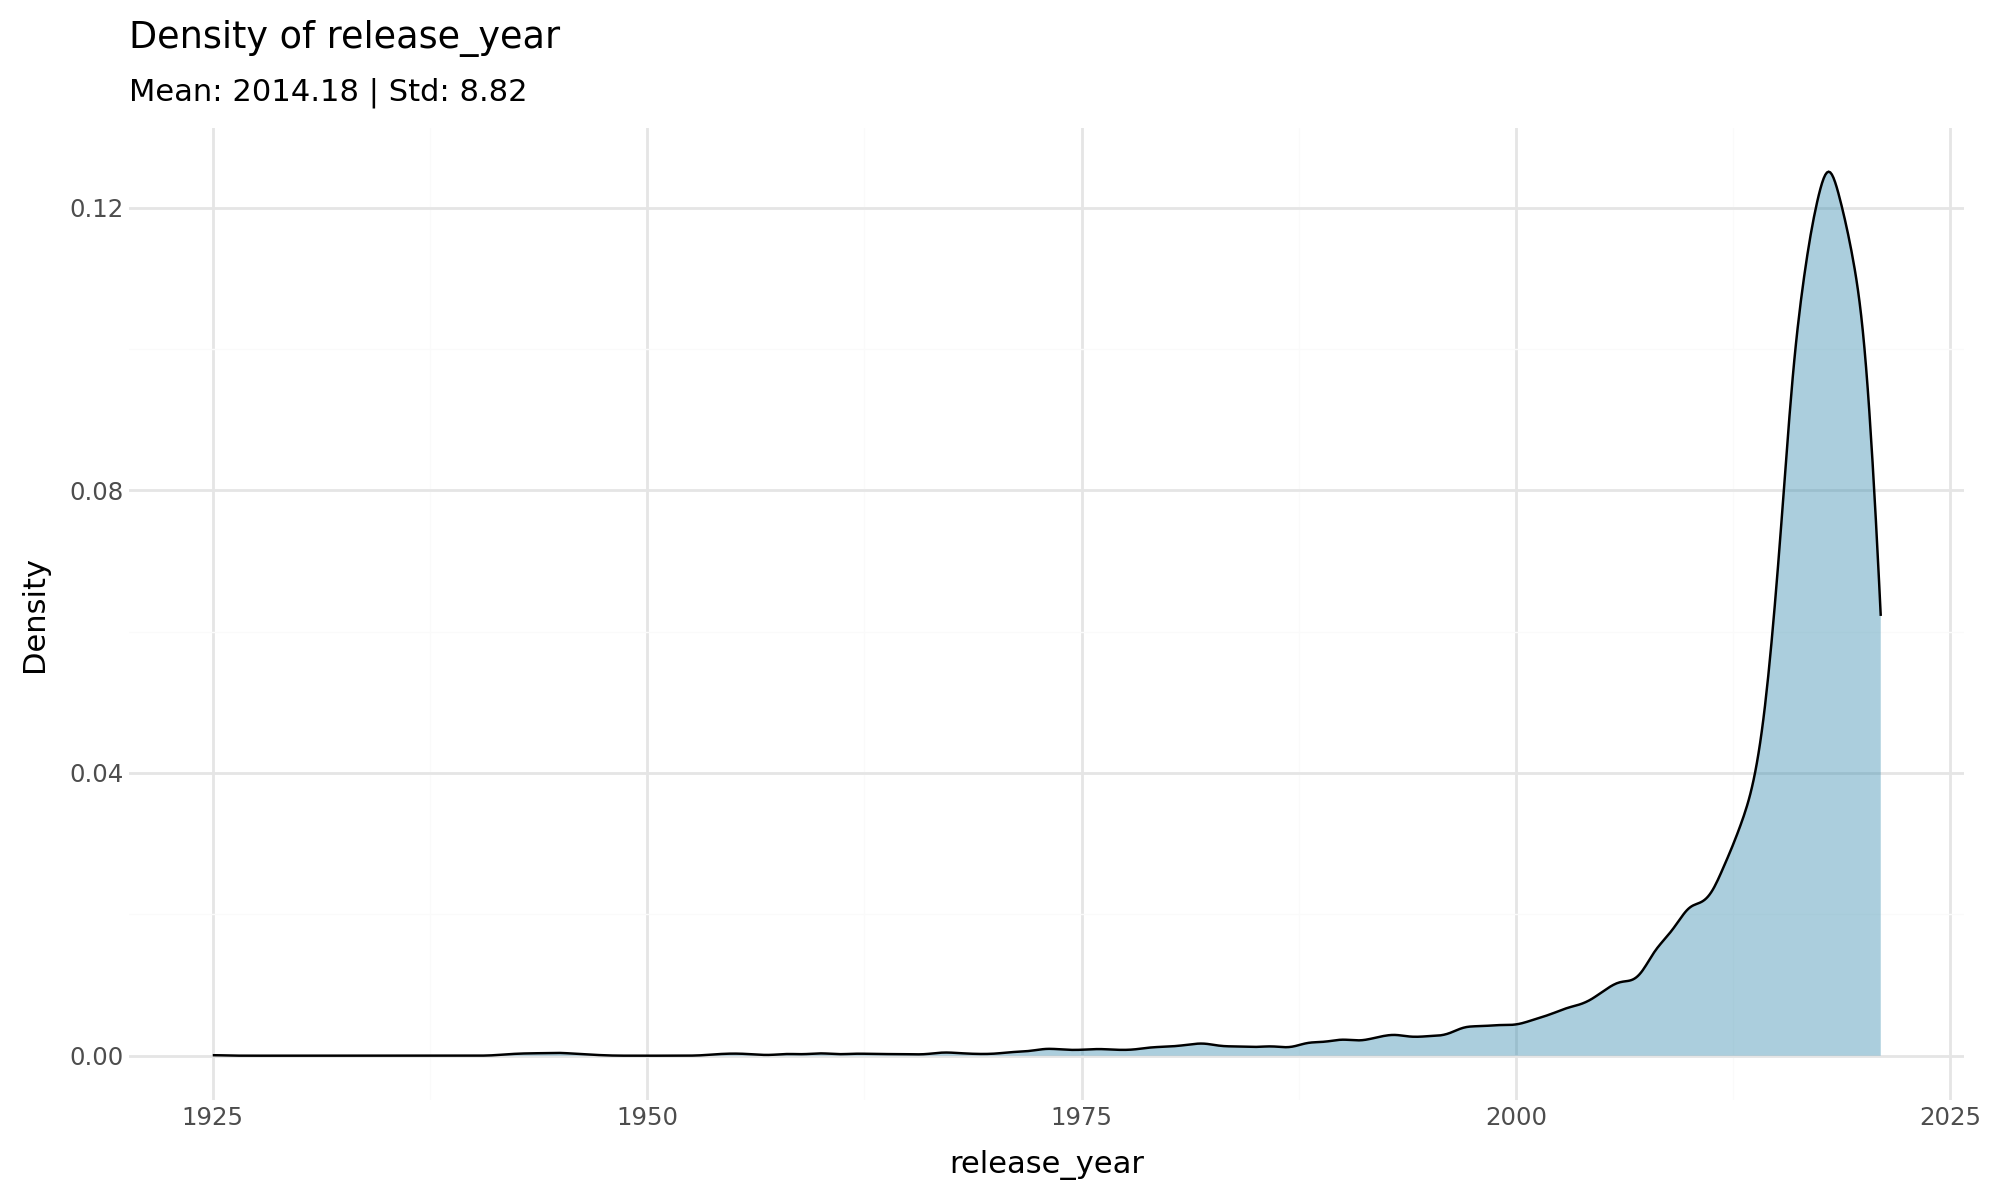

In [25]:
plot_density(netflix, 'release_year')

<ggplot: (1000 x 600)>


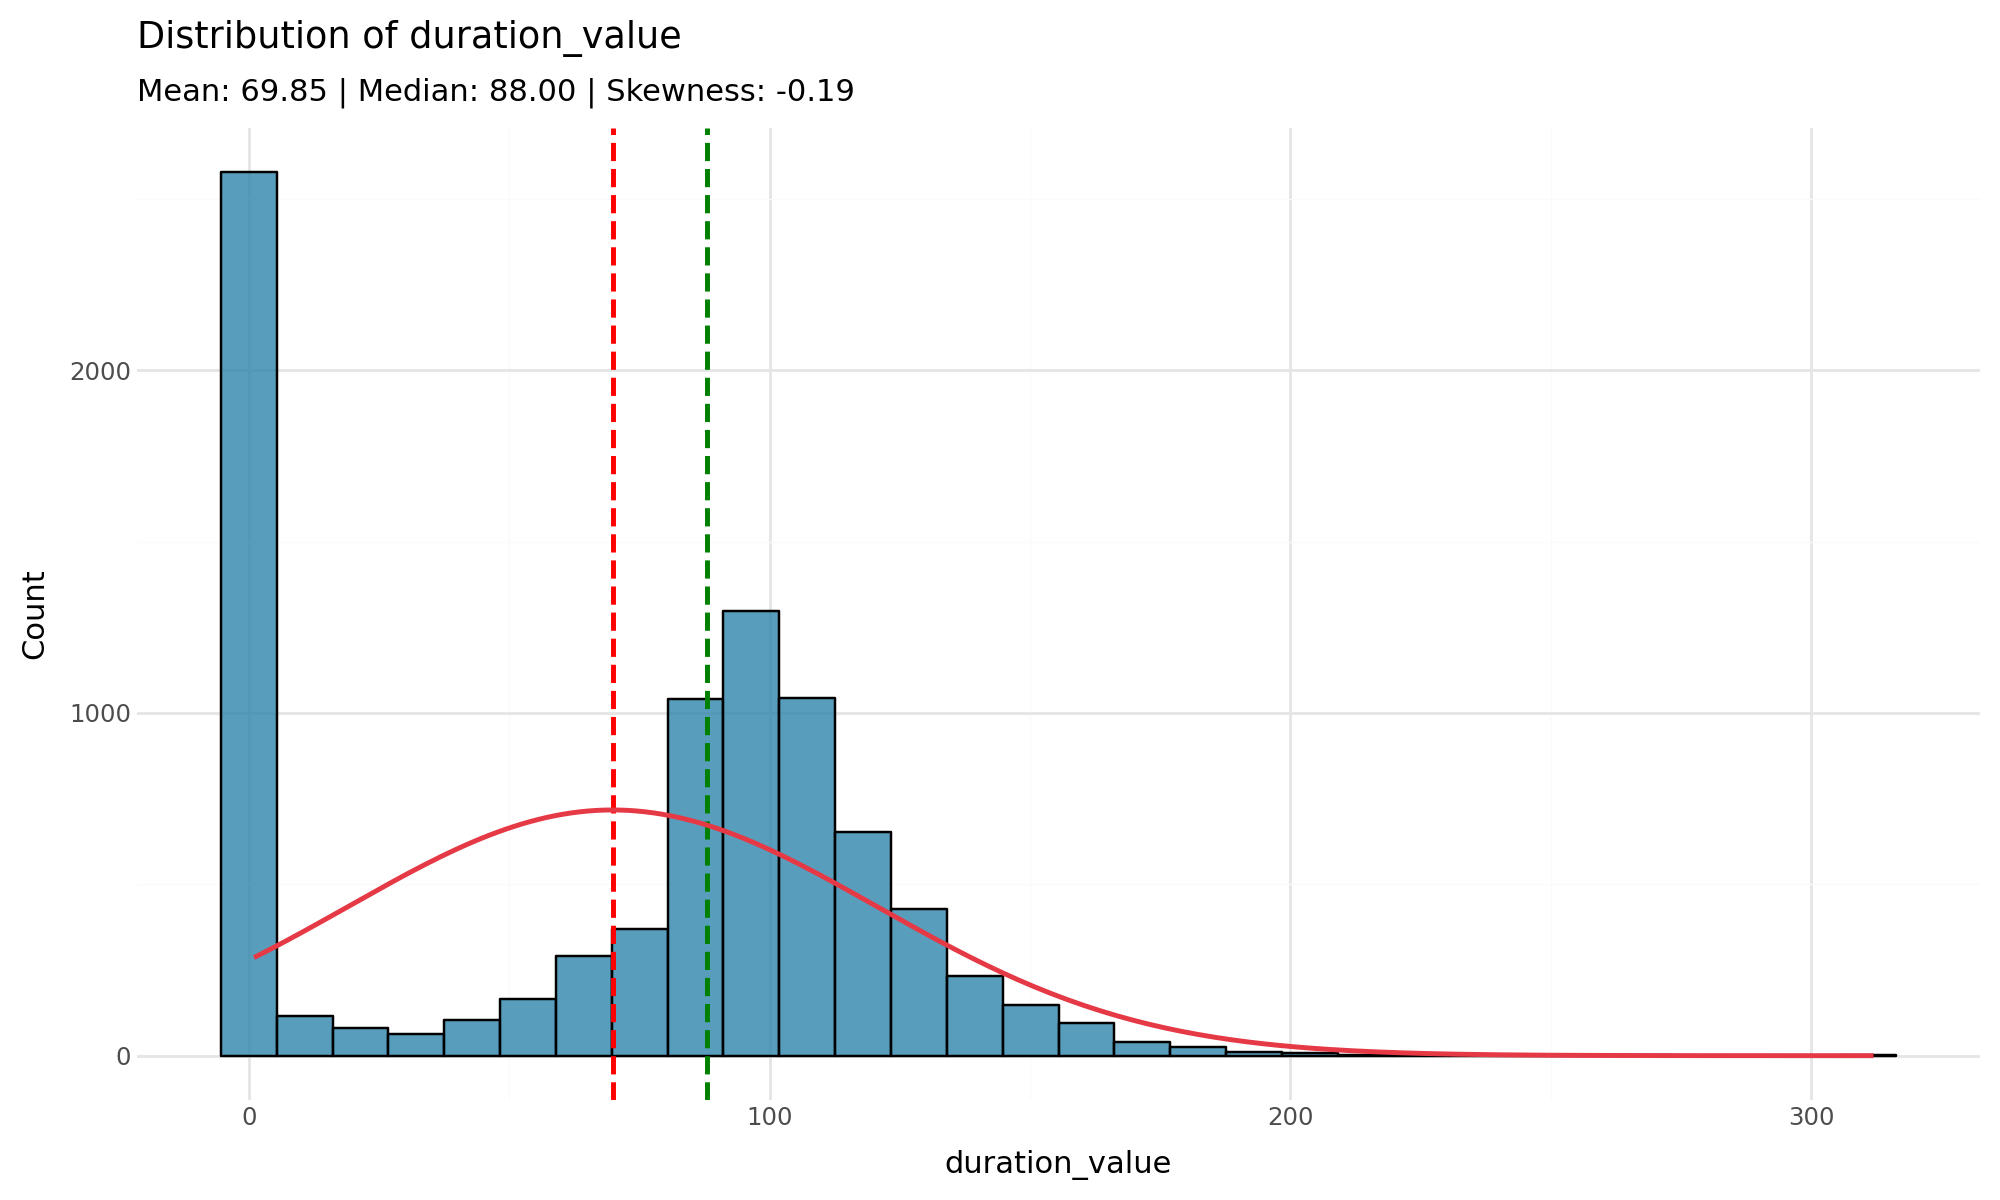

In [26]:
plot_distribution(netflix, 'duration_value', show_bell = True)

###  Movies vs. TV Shows distribution

In [51]:
type_counts = netflix['type'].value_counts()
type_counts

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

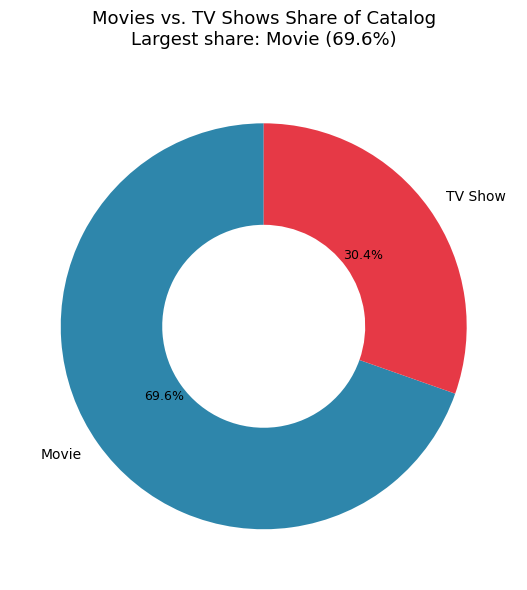

In [52]:
plot_donut(netflix, 'type', figsize=(6,6), title='Movies vs. TV Shows Share of Catalog')

###  Content added by year

In [47]:
content_by_year = netflix[~netflix['date_added_missing']].groupby('year_added').size().reset_index(name='Number Of Titles')
content_by_year

,year_added,Number Of Titles
0,2008.0,2
1,2009.0,2
2,2010.0,1
3,2011.0,13
4,2012.0,3
5,2013.0,11
6,2014.0,24
7,2015.0,82
8,2016.0,429
9,2017.0,1188


<ggplot: (1000 x 600)>


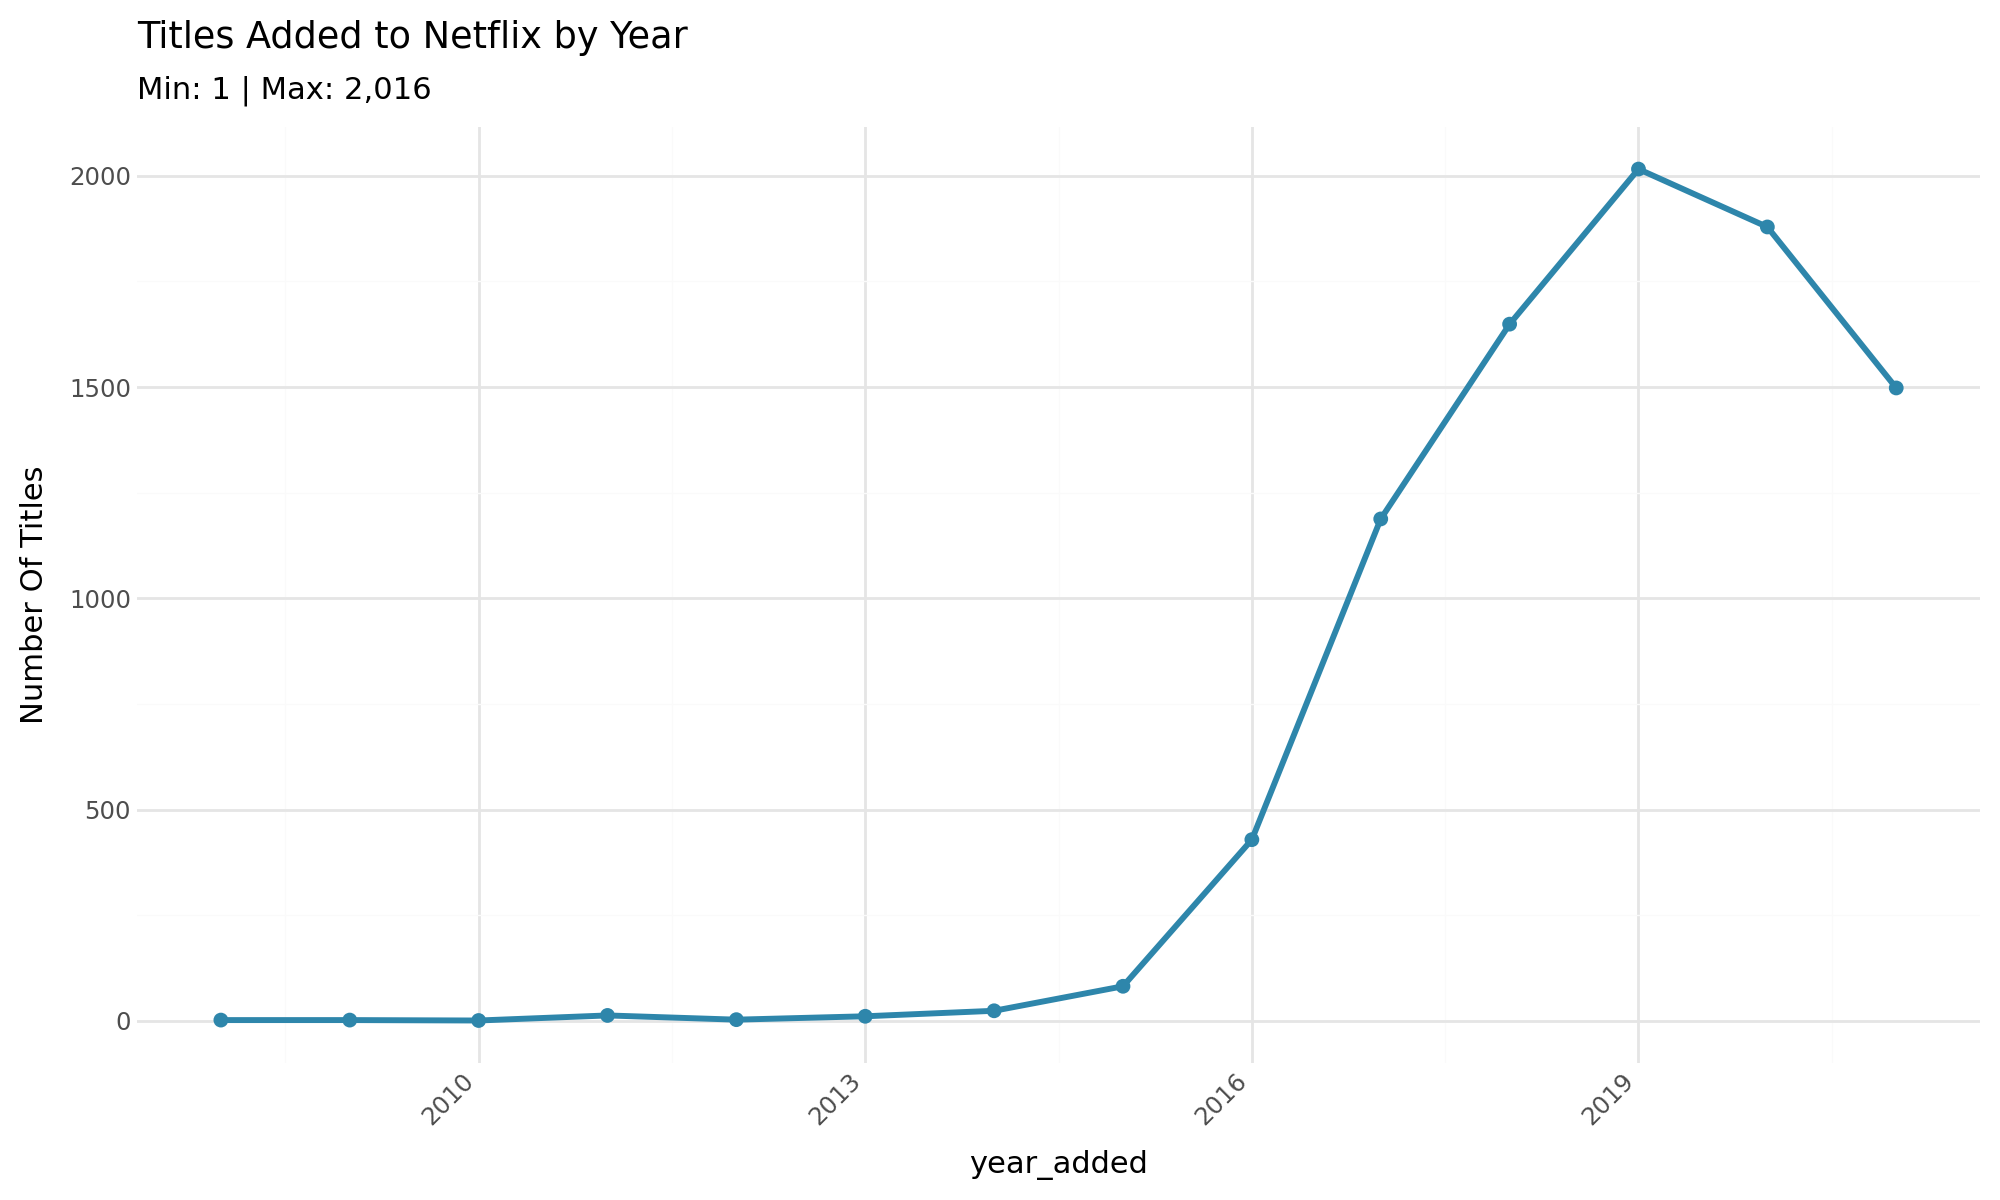

In [50]:
# Convert the series to a dataframe first
plot_line(content_by_year, 'year_added', 'Number Of Titles', title='Titles Added to Netflix by Year', show_points=True, line_size=1.2)

### Top content-producing countries

In [53]:
top_countries = (netflix[netflix['primary_country'] != 'Unknown']['primary_country']
                  .value_counts().head(10)).reset_index()
top_countries.columns = ['primary_country', 'count']
top_countries

,primary_country,count
0,United States,3211
1,India,1008
2,United Kingdom,628
3,Canada,271
4,Japan,259
5,France,212
6,South Korea,211
7,Spain,181
8,Mexico,134
9,Australia,117


<ggplot: (1000 x 600)>


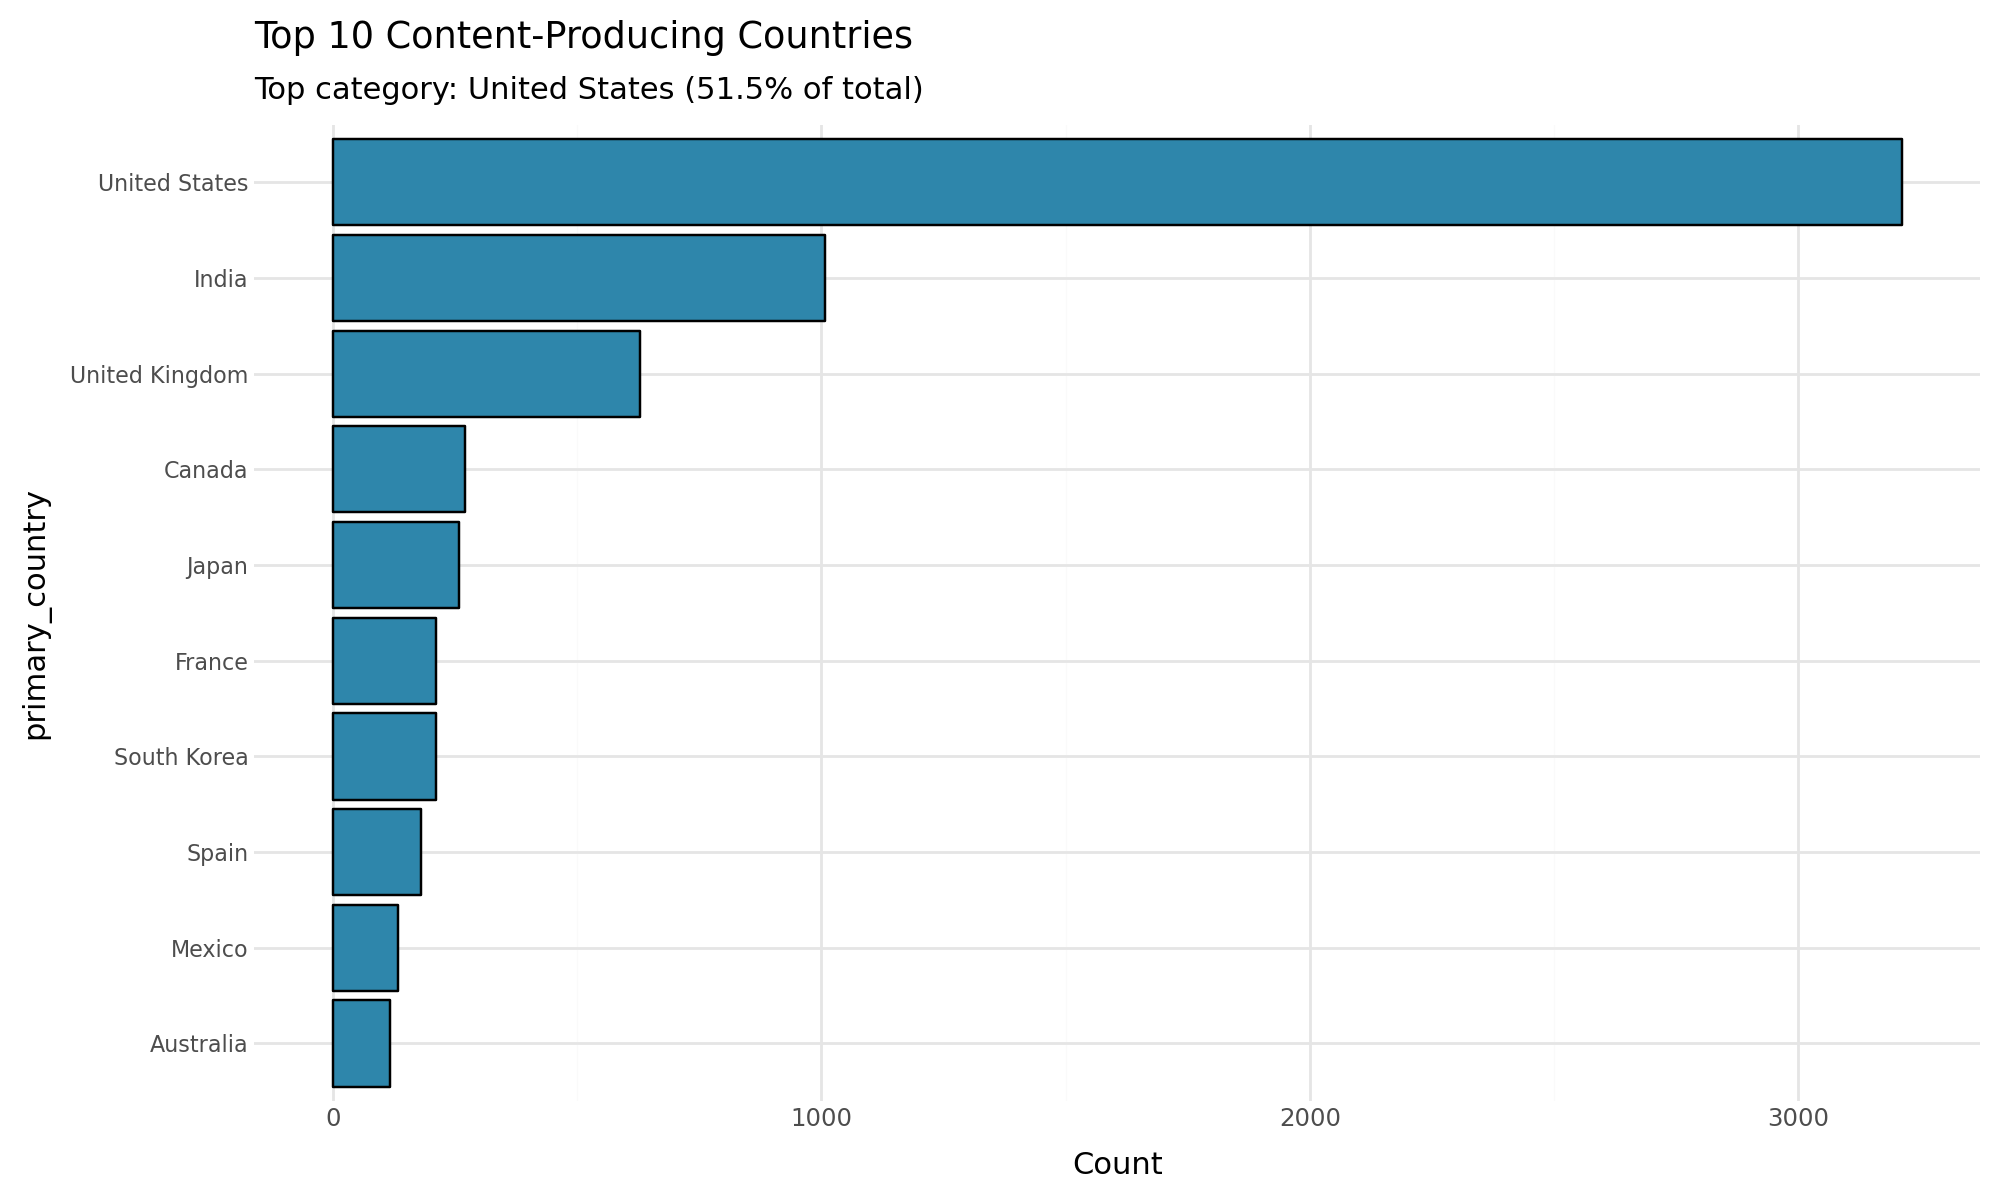

In [54]:
plot_bar(top_countries, 'primary_country', 'count', title='Top 10 Content-Producing Countries')

### Most common ratings

In [59]:
top_ratings = netflix['rating'].value_counts().head(10).reset_index(name='Number of Title')
top_ratings

,rating,Number of Title
0,TV-MA,3207
1,TV-14,2160
2,TV-PG,863
3,R,799
4,PG-13,490
5,TV-Y7,334
6,TV-Y,307
7,PG,287
8,TV-G,220
9,NR,80


<ggplot: (1000 x 600)>


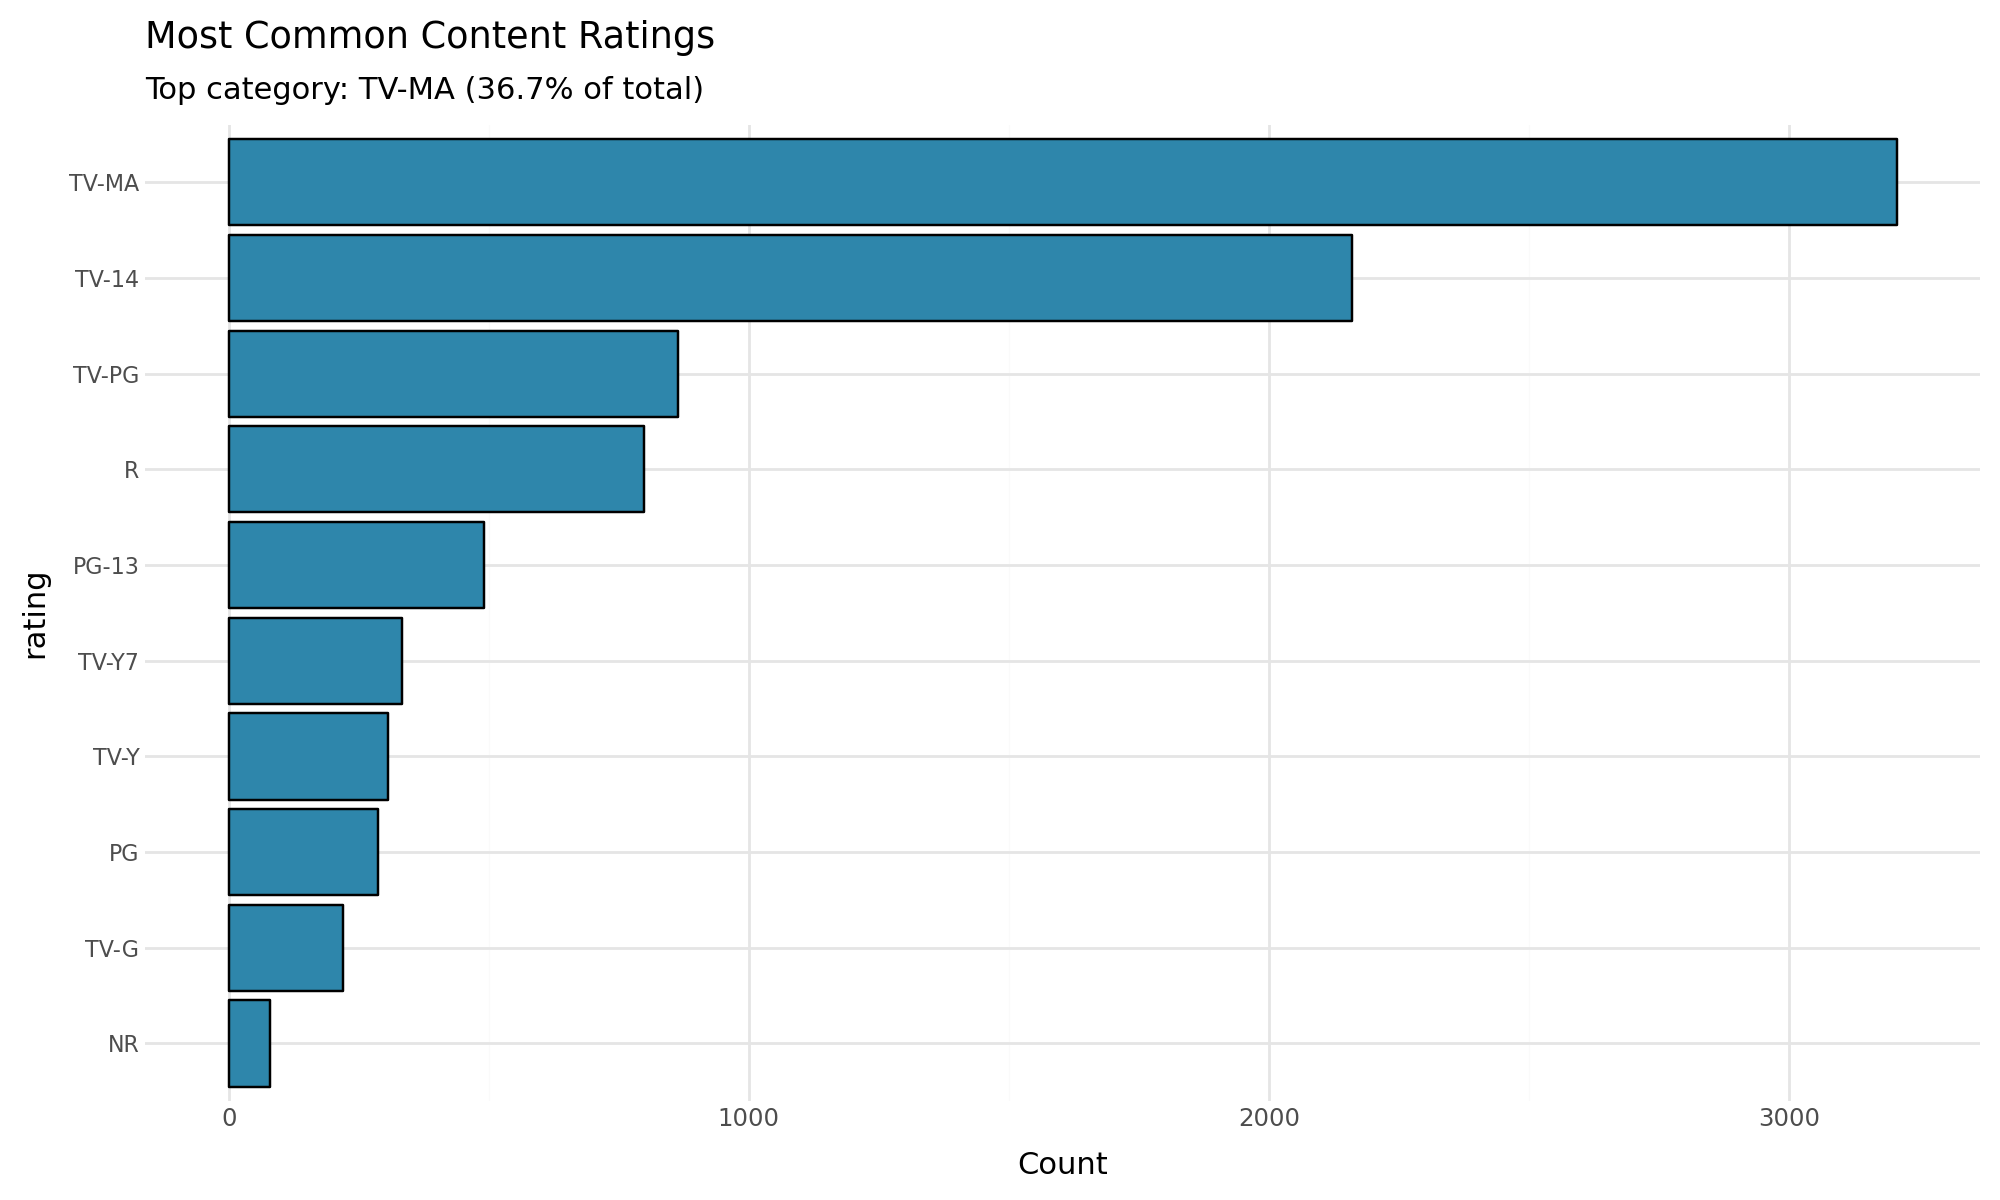

In [60]:
plot_bar(top_ratings, 'rating', 'Number of Title', title='Most Common Content Ratings')

###  Most common genres

In [35]:
top_genres = netflix['listed_in'].str.split(', ').explode().value_counts().head(10).reset_index()
top_genres

,listed_in,count
0,International Movies,2752
1,Dramas,2427
2,Comedies,1674
3,International TV Shows,1351
4,Documentaries,869
5,Action & Adventure,859
6,TV Dramas,763
7,Independent Movies,756
8,Children & Family Movies,641
9,Romantic Movies,616


<ggplot: (1000 x 600)>


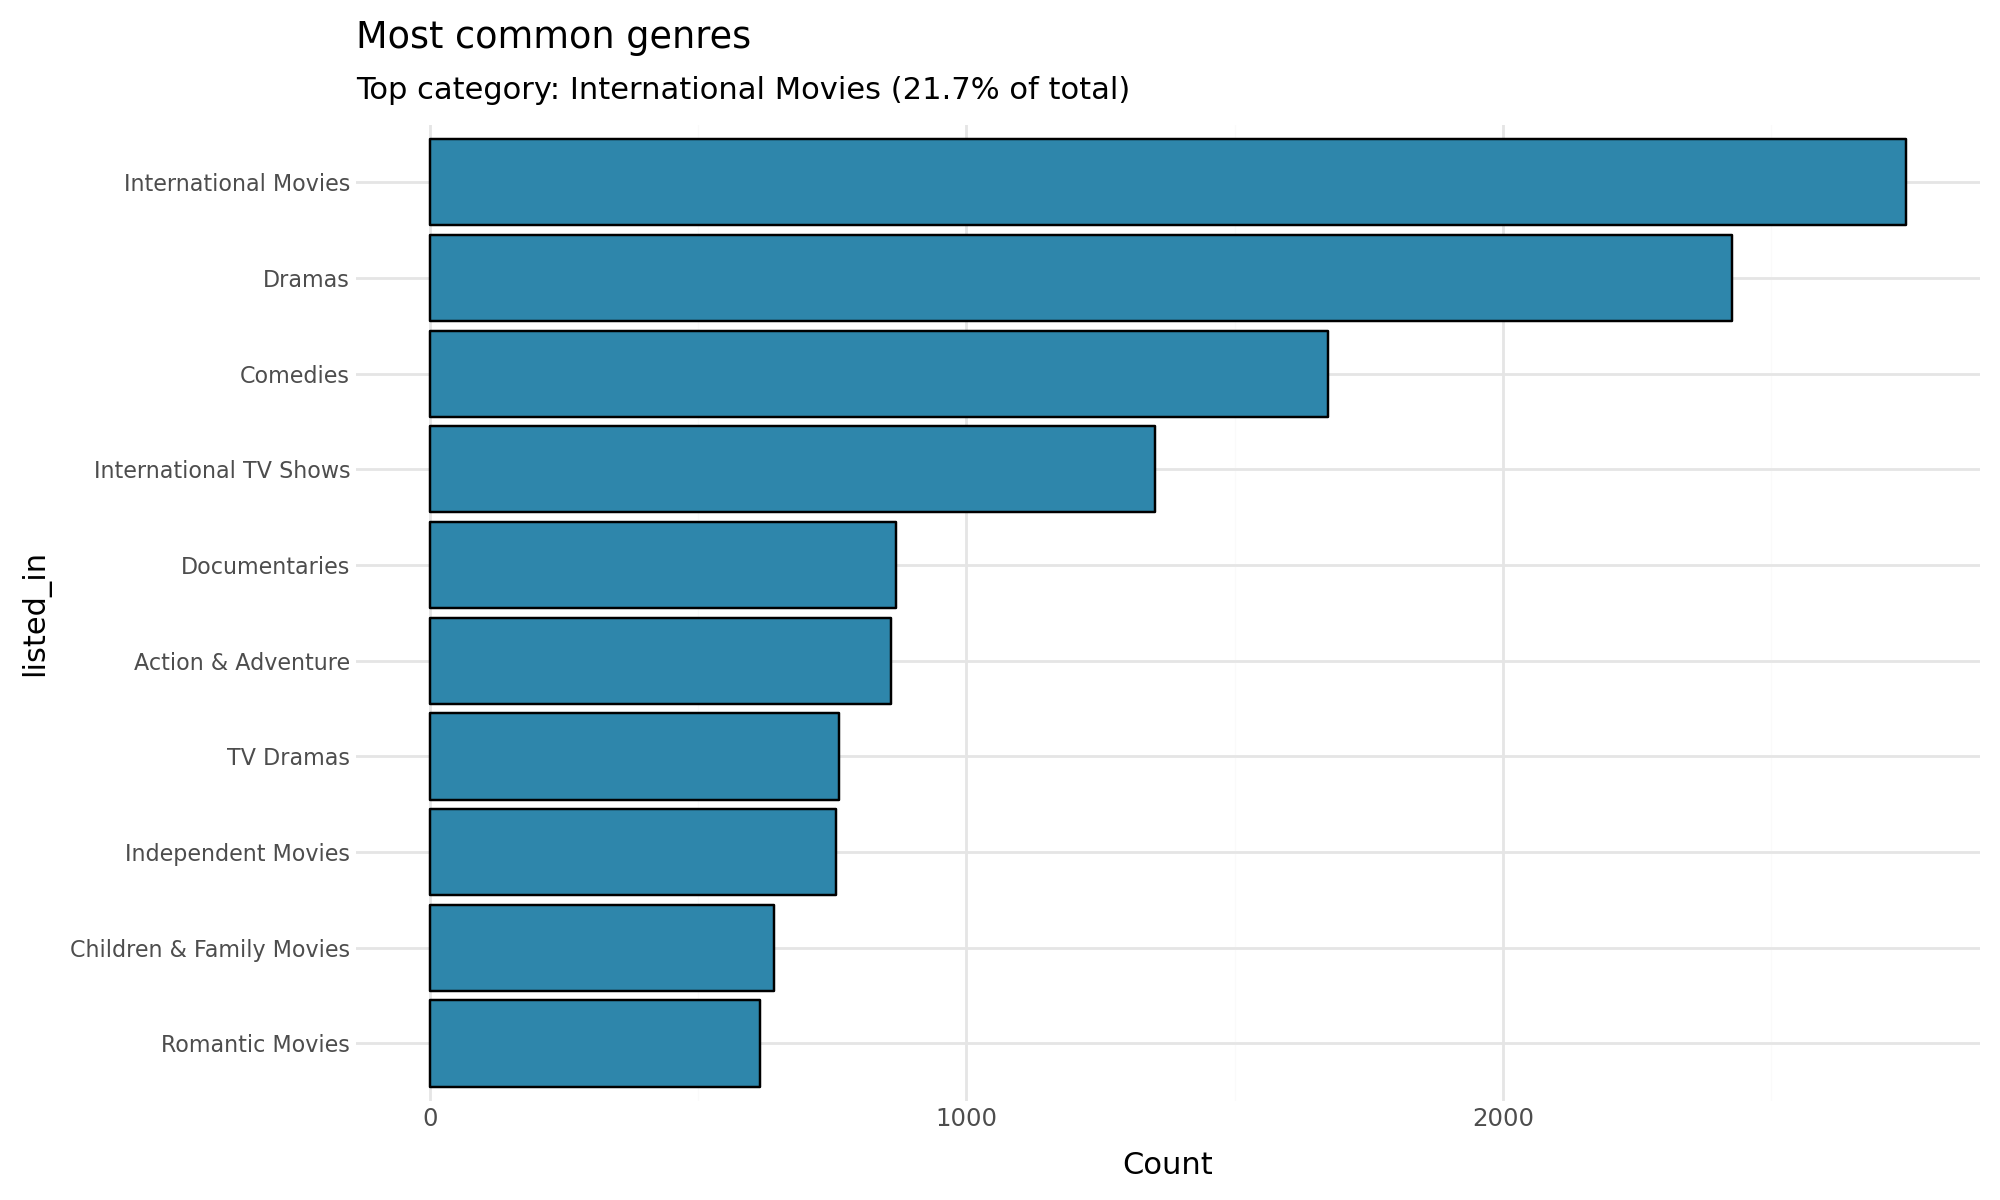

In [61]:
plot_bar(top_genres, 'listed_in', 'count', title='Most common genres')

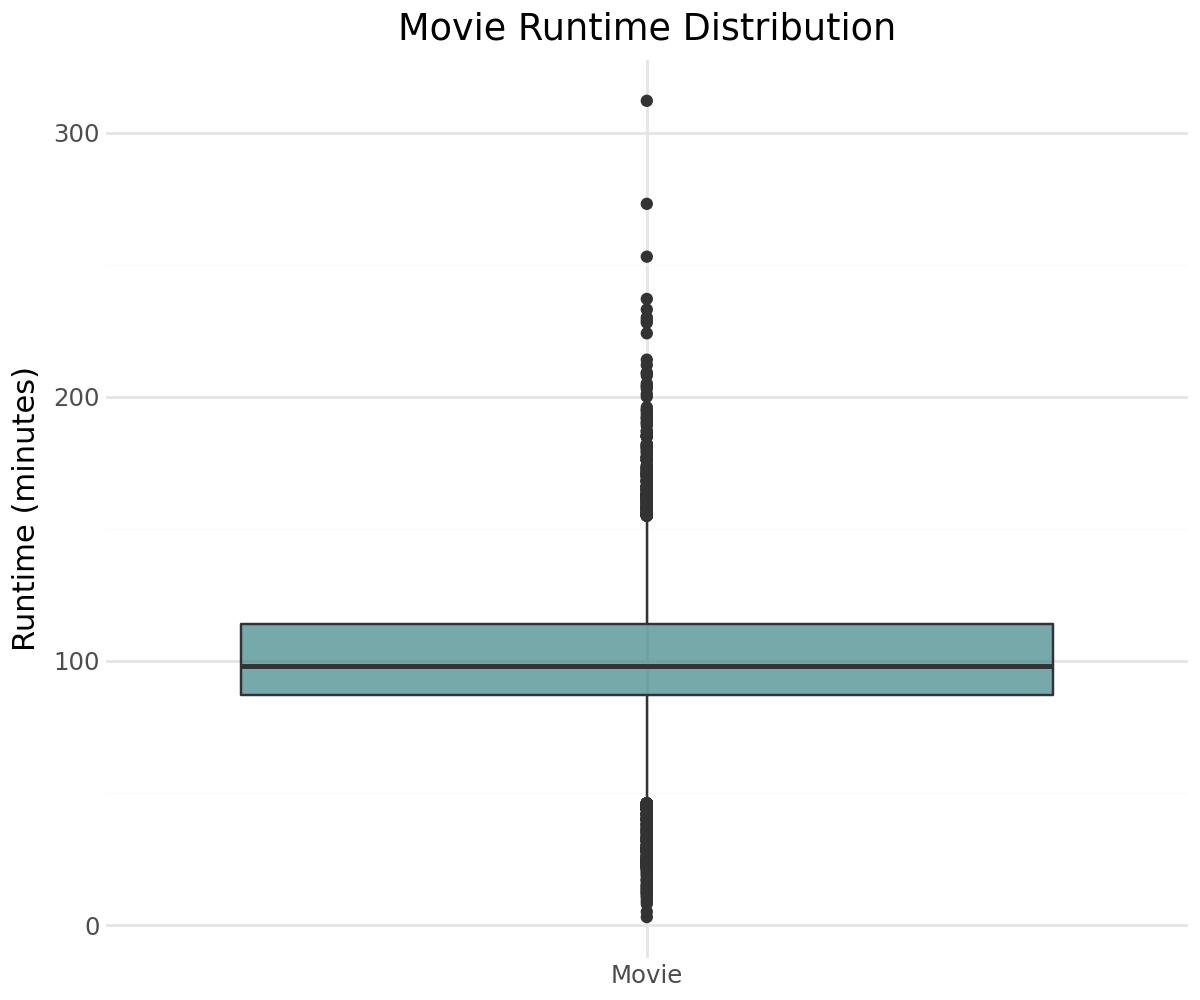

In [39]:
box_df = netflix[(netflix['type'] == 'Movie') & (~netflix['duration_missing'])]

(ggplot(box_df, aes(x='type', y='duration_value'))
 + geom_boxplot(fill='#3B8686', alpha=0.7)
 + labs(title='Movie Runtime Distribution', x='', y='Runtime (minutes)')
 + theme_minimal()
 + theme(figure_size=(6, 5)))

## Insights

1. **Movies dominate the catalog roughly 2-to-1 over TV shows.** Netflix's library, as of this snapshot, is
   built primarily around standalone films rather than episodic series (see Chart 1).

2. **Catalog growth was explosive from 2015-2019, then plateaued.** Titles added per year jumped from double
   digits to well over a thousand within a few years, then leveled off and slightly declined by 2020-2021,
   suggesting a shift from aggressive content acquisition toward a maturing, more selective catalog strategy
   (see Chart 2).

3. **The US and India are the two dominant production countries by far.** The United States alone accounts
   for a large share of titles with a known country of origin, with India a distant but clear second — most
   other countries appear far less frequently (see Chart 3).

4. **The catalog skews toward mature content.** TV-MA and TV-14 together outnumber every family-friendly
   rating combined, indicating Netflix's catalog is weighted toward teen/adult audiences rather than young
   children (see Chart 4).

5. **Movie runtimes are tightly standardized.** The vast majority of movies fall in a narrow 85-115 minute
   band, showing the catalog leans on conventional feature-length films rather than unusually short or long
   content (see Chart 5).